# 问题三：算力约束下的条件资源优化与结构转移

**主线：固定领域配比与质量情景 → 把预算分配给参数、训练数据和提质 → 检验预算变化是否改变最优质量状态。**

本文承接问题二共同指数修正，采用用户已确认的七项选择。主结果以参考配比为条件，所有结果均为模型预测，不是新增大模型训练实测。质量上限是样本筛选参照的情景上限，不能解释为天然质量极限。

## 1. 输入、题意与证据边界

输入来自前两问当前接口、质量核查及C7；核对哈希和评分后使用，不重新拟合前两问。参数量与数据量采用十亿单位。未知域的基线沿用问题一填补，新增提质收益取零，这是已确认约定。

In [1]:
from pathlib import Path
import sys,json,hashlib,platform,subprocess,zipfile,xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import differential_evolution, minimize, brentq
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display,Markdown,Image
ROOT=Path.cwd()
assert (ROOT/'Q3/resource_model.py').exists(), '请从项目根目录运行'
sys.path.insert(0,str(ROOT))
from Q3.resource_model import ResourceModel,Scenario,COSTS,COST_LABELS,ETA_ATT,QUALITY_TOL,OBJECTIVE_RTOL,g,gp
OUT=ROOT/'output_q3_resource'; TAB=OUT/'tables'; FIG=OUT/'figures'
for path in [OUT,TAB,FIG]:path.mkdir(parents=True,exist_ok=True)
def sha(p):return hashlib.sha256(Path(p).read_bytes()).hexdigest()
def save(df,name):
    df.to_csv(TAB/f'{name}.csv',index=False,encoding='utf-8-sig');return df
def show(s):display(Markdown(s))
def dump(x,name): (OUT/name).write_text(json.dumps(x,ensure_ascii=False,indent=2,allow_nan=False)+'\n')
pd.set_option('display.max_columns',16)
pd.set_option('display.precision',6)
fonts={f.name for f in font_manager.fontManager.ttflist}
for f in ['Arial Unicode MS','PingFang SC','Heiti SC','Noto Sans CJK SC']:
    if f in fonts:plt.rcParams['font.family']=f;break
plt.rcParams.update({'axes.unicode_minus':False,'figure.dpi':110,'savefig.dpi':160,
                    'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
protected=[ROOT/x for x in ['0924_F题_问题一.ipynb','notebook_source.py','0924_问题二.ipynb','Q2/notebook_source.py',
           'output_q1/length_domain_calibrated22/tables/q1_outputs_for_q2_q3.json','output_q2_shared/q2_interface.json']]
protected_before={str(p.relative_to(ROOT)):sha(p) for p in protected}
q1=json.loads(protected[-2].read_text()); q2=json.loads(protected[-1].read_text())
assert sha(protected[-2])==q2['q1_interface_sha256']
subprocess.run([sys.executable,str(ROOT/'Q3/audit_quality_interface.py')],cwd=ROOT,check=True,capture_output=True,text=True)
audit=json.loads((ROOT/'Q3/quality_audit/verification.json').read_text())
assert audit['status']=='passed' and audit['domain_means_match_current_interface']
with zipfile.ZipFile(ROOT/'算力约束下提升大语言模型能力的资源配置建模.docx') as z:
    xml=ET.fromstring(z.read('word/document.xml'))
paragraphs=[''.join(p.itertext()) for p in xml.findall('.//{http://schemas.openxmlformats.org/wordprocessingml/2006/main}p')]
text='\n'.join(paragraphs)
assert 'η=2×10-4' in text and 'γ=107' in text and 'λ=6.0' in text
assert 'γ=5×109' in text and 'λ=4.0' in text and 'γ=2×109' in text and 'λ=10.0' in text
c7_path=ROOT/'real_attachments/C_efficiency_evolution/model_architecture_metadata.csv'
c7=pd.read_csv(c7_path); contexts=sorted(c7.max_position_embeddings.astype(int).unique().tolist())
assert contexts==[2048,4096,8192,32768,131072]
coverage=[]
for key,file,nature in [('B1','pythia_training_log_existing.csv','规模轨迹，按原项目来源标注'),
                        ('B7','supplementary_NQ_experiment_expanded.csv','半合成质量实验')]:
    d=pd.read_csv(ROOT/'real_attachments/B_scaling_laws'/file)
    coverage.append({'source':key,'nature':nature,'n':len(d),'N_min':d.N_params_B.min(),'N_max':d.N_params_B.max(),
                     'D_min':d.D_tokens_B.min(),'D_max':d.D_tokens_B.max()})
coverage=pd.DataFrame(coverage);display(save(coverage,'observation_coverage'))
context_table=pd.DataFrame({'L_ctx':contexts,'attention_training_ratio':np.array(contexts)*ETA_ATT/6})
display(save(context_table,'context_cost_ratios'))
model=ResourceModel(q2)
versions={'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
          'scipy':scipy.__version__,'matplotlib':matplotlib.__version__}
dump(versions,'versions.json')
show(f'核查通过：{audit["raw_rows"]:,}条评分合并为{audit["unique_rows"]:,}篇，域均值与接口一致。C7含{len(c7)}条架构记录。注意力与基础训练成本相等的临界窗口为 **{6/ETA_ATT:.0f}**。C7窗口仅为外生情景代理，不等同于所有训练样本实际长度。')

,source,nature,n,N_min,N_max,D_min,D_max
0,B1,规模轨迹，按原项目来源标注,1176,0.070542,11.965825,0.134,299.893
1,B7,半合成质量实验,450,0.070000,11.970000,10.000,600.000


,L_ctx,attention_training_ratio
0,2048,0.068267
1,4096,0.136533
2,8192,0.273067
3,32768,1.092267
4,131072,4.369067


核查通过：272,505条评分合并为261,086篇，域均值与接口一致。C7含45条架构记录。注意力与基础训练成本相等的临界窗口为 **30000**。C7窗口仅为外生情景代理，不等同于所有训练样本实际长度。

## 2. 质量接口与成本模型

$Q$＝问题一文档评分及其混合质量指数；$u=Q-Q_0(p)$＝同配比下的额外质量增量；$z=T(Q)$＝成本刻度。三个变量不能互换。固定A1七域等权分布的1%和99%锚点，使用线性映射，不逐篇截断评分。

$$Q_0(p)=\sum_jp_jQ_j,\quad h(p)=\frac{f(p)-f(p_0)}{s_L},\quad
T(Q)=\frac{Q-q_{\rm low}}{q_{\rm high}-q_{\rm low}}.$$

对有质量映射的域集合$\mathcal M$，用域内最高$r$比例文档的均值$\mu_{d(j)}(r)$定义上限参照：
$$u_{\max}(p;r)=\sum_{j\in\mathcal M}p_j\kappa_j[\mu_{d(j)}(r)-\mu_{d(j)}(1)].$$
主情景$r=0.5$，敏感性$r=0.2$；缺失域新增收益为零，原$\bar Q$不变。选择上限并不强制实际筛选比例；中间质量水平的连续可调性是模型假设。

$$L=E_B+(A_BN^{-\alpha}+B_BD^{-\nu})\exp[-\theta_Q u/s_Q+\eta_ph(p)].$$

采用B1基线；$s_Q=1$为主、0.5和2作敏感性，$\lambda=\theta_Q/s_Q$只是条件值。配比修正迁移至B1及正向提质效果仍是工作假设。

$$C_{\rm train}=6\times10^{18}ND,\quad C_{\rm att}=2\times10^{-4}L_{ctx}\times10^{18}ND,$$
$$C_Q=10^9D[g(z)-g(z_0)],\quad z=T(Q_0+u),\quad z_0=T(Q_0),\quad 0\le u\le u_{\max}.$$
$$g_{\exp}(z)=10^7e^{6z},\quad g_{\rm power}(z)=5\times10^9z^4,\quad g_{\log}(z)=2\times10^9\ln(1+10z).$$

三种成本并列比较，不重新标定题设参数。训练、注意力和提质共用同一个$D$，成本代理不等同于真实筛选流水线。域内最高50%文档的词数保留率随域而异，不能当作50%的Token保留率。

In [2]:
caps=pd.read_csv(ROOT/'Q3/quality_audit/quality_cap_candidates.csv')
anchors=pd.read_csv(ROOT/'Q3/quality_audit/anchor_sensitivity.csv')
anchor=anchors.loc[anchors.population.eq('A1_only')].iloc[0]
lo,hi=float(anchor.balanced_q01),float(anchor.balanced_q99)
domains=q2['domain_order'];coef=np.array([q2['log_linear']['a_i'][d] for d in domains])
def make_scenario(recipe='p0',s_q=1.,keep=.5):
    p=np.array(q2['p0'] if recipe=='p0' else q2['p_star'])
    assert np.isclose(p.sum(),1) and (p>=0).all()
    q0=float(p@np.array(q2['Q_domain']))
    f=q2['log_linear']['intercept']+np.log(p+q2['log_linear']['epsilon'])@coef
    h=float((f-q2['h_anchor'])/q2['h_scale'])
    cap=caps.loc[caps.recipe.eq(recipe)&np.isclose(caps.keep,keep)].iloc[0]
    assert np.isclose(q0,cap.Q0,atol=1e-12)
    return Scenario(recipe,q0,h,float(cap.u_cap_candidate),s_q,keep,lo=lo,hi=hi)
main_sc=make_scenario()
scenarios={'main':main_sc,'p_star':make_scenario('p_star'),'sQ_0.5':make_scenario(s_q=.5),
           'sQ_2':make_scenario(s_q=2.),'keep_20pct':make_scenario(keep=.2)}
interface_rows=[]
for name,sc in scenarios.items():
    interface_rows.append({'scenario':name,**sc.__dict__,'lambda_conditional':model.theta/sc.s_q,
                           'z0':(sc.q0-lo)/(hi-lo),'z_max':(sc.q0+sc.cap-lo)/(hi-lo)})
display(save(pd.DataFrame(interface_rows),'quality_interfaces'))
config={'target_source':'B1','parameters':q2['B1'],'theta_Q':model.theta,'eta_p':model.eta,'eta_att':ETA_ATT,
        'T':{'reference':'A1 seven domains equally weighted','q_low':lo,'q_high':hi},
        'costs':{'exponential':{'gamma':1e7,'shape':6.},'power':{'gamma':5e9,'shape':4.},'logarithmic':{'gamma':2e9,'shape':10.}},
        'scenarios':{k:v.__dict__ for k,v in scenarios.items()},'p0':q2['p0'],'p_star':q2['p_star'],'domain_order':domains,
        'log_linear':q2['log_linear'],'h_anchor':q2['h_anchor'],'h_scale':q2['h_scale'],
        'units':{'N':'billion parameters','D':'billion tokens','C':'FLOPs'},'contexts':contexts,
        'numerics':{'quality_state_tolerance':QUALITY_TOL,'near_optimal_relative_tolerance':OBJECTIVE_RTOL,
                    'outer_grid_default':65,'outer_grid_check':257,'logN_brent_xtol':1e-12},
        'physical_bounds':'N>0,D>0; observational ranges are not physical constraints',
        'supply':'same D cost proxy; no raw token supply guarantee'}
dump(config,'config.json')
show(f'主质量上限 **u_max={main_sc.cap:.6f}**，对应 **Q_max={main_sc.q0+main_sc.cap:.6f}**、**z_max={(main_sc.q0+main_sc.cap-lo)/(hi-lo):.6f}**。达到上限是u=u_max，不是z=1。主配比中43.54%的份额无质量样本；p*中该份额为54.66%，这些域本次不计新增收益。')

,scenario,recipe,q0,h,cap,s_q,keep,mapping,lo,hi,lambda_conditional,z0,z_max
0,main,p0,-0.080148,0.000000,0.113672,1.0,0.5,A1_balanced_q01_q99,-1.032467,0.645293,0.396659,0.567613,0.635365
1,p_star,p_star,-0.082576,-0.397288,0.092007,1.0,0.5,A1_balanced_q01_q99,-1.032467,0.645293,0.396659,0.566166,0.621005
2,sQ_0.5,p0,-0.080148,0.000000,0.113672,0.5,0.5,A1_balanced_q01_q99,-1.032467,0.645293,0.793319,0.567613,0.635365
3,sQ_2,p0,-0.080148,0.000000,0.113672,2.0,0.5,A1_balanced_q01_q99,-1.032467,0.645293,0.198330,0.567613,0.635365
4,keep_20pct,p0,-0.080148,0.000000,0.190757,1.0,0.2,A1_balanced_q01_q99,-1.032467,0.645293,0.396659,0.567613,0.681310


主质量上限 **u_max=0.113672**，对应 **Q_max=0.033524**、**z_max=0.635365**。达到上限是u=u_max，不是z=1。主配比中43.54%的份额无质量样本；p*中该份额为54.66%，这些域本次不计新增收益。

## 3. 条件最优推导与数值核验

求解$\min_{N,D,u}L$，约束总成本不超过$C$，$N,D>0$及$0\le u\le u_{\max}$。固定$u,p$后，正的共同乘子不改变规模项的条件最优，但质量成本改变可用预算。

令$k=10^{18}(6+\eta_{att}L_{ctx})$、$c(u)=10^9[g(z)-g(z_0)]$。损失随$D$严格下降，因此预算取等号，$D=C/(kN+c)$。令$x=\ln N$，内层目标为
$$F(x)=Ae^{-\alpha x}+BC^{-\nu}(ke^x+c)^\nu.$$
$$F''(x)=\alpha^2Ae^{-\alpha x}+BC^{-\nu}\nu ke^x(ke^x+c)^{\nu-2}(c+\nu ke^x)>0.$$
两端目标趋于无穷，所以固定质量下存在唯一最优解。KKT条件＝约束最优的一阶平衡条件：
$$\alpha AN^{-\alpha}=\nu BD^{-\nu}\frac{kN}{kN+c}.$$
用自适应扩大区间的求根解算，不以计算边界代替资源边界；$c=0$时恢复经典算力分配。

外层比较两端点和检测到的全部内点候选，并对网格加密。沿内层最优分支，外层导数为正乘子乘以下式：
$$M(u)=-\lambda(t_N+t_D)+\frac{\nu t_D c'(u)}{kN+c},\quad
c'(u)=\frac{10^9g'(z)}{q_{high}-q_{low}}.$$
单边导数只给局部边界条件，最终仍需比较目标。对数成本为凹函数，不能预设外层单峰或R0→R1→R2的次序。
将$M(u_b)=0$与内层KKT联立，令$W=kN_b$，可得到质量边界$u_b$上的局部转移候选：
$$W=\frac{\nu c'(u_b)/\lambda-c(u_b)}{1+\nu/\alpha},\quad
N_b=W/k,\quad D_b=\left[\frac{\nu B}{\alpha A}\frac{W}{W+c}N_b^\alpha\right]^{1/\nu},\quad C_b=D_b(W+c).$$
仅在$W>0$时存在正规模候选；是否为实际全局转移仍需候选损失比较。对固定质量边界，其候选预算随上下文成本系数按$k^{-\alpha/\nu}$变化。

求解器实现位于`Q3/resource_model.py`；以下使用独立二维优化、有限差分、经典解析解和扩大括区间等方式核验。数值核验检验程序与模型的一致性，不验证模型的真实训练效果。

In [3]:
validation=[]
for cost in COSTS:
    for C in [1e19,1e22,1e24]:
        for ctx in [2048,131072]:
            k=1e18*(6+ETA_ATT*ctx)
            classicN=(model.alpha*model.A/(model.nu*model.B)*(C/k)**model.nu)**(1/(model.alpha+model.nu))
            r0=model.inner(C,ctx,cost,main_sc,0.)
            mid=.43*main_sc.cap; r=model.inner(C,ctx,cost,main_sc,mid)
            du=main_sc.cap*1e-4
            fd=(model.inner(C,ctx,cost,main_sc,mid+du)['reducible_loss']-model.inner(C,ctx,cost,main_sc,mid-du)['reducible_loss'])/(2*du)
            exact=r['M']*np.exp(-model.theta/main_sc.s_q*mid+model.eta*main_sc.h)
            wide=model.inner(C,ctx,cost,main_sc,mid,bracket_padding=12.)
            validation.append({'cost':cost,'C':C,'L_ctx':ctx,
                'classic_N_relative_error':abs(r0['N_B']/classicN-1),
                'derivative_relative_error':abs(fd-exact)/max(abs(exact),1e-8),
                'expanded_bracket_relative_error':abs(wide['N_B']/r['N_B']-1),
                'inner_kkt_log_residual':r['kkt_log_residual']})
validation=pd.DataFrame(validation);display(save(validation,'analytic_checks'))
assert validation.classic_N_relative_error.max()<1e-10
assert validation.derivative_relative_error.max()<1e-5
assert validation.expanded_bracket_relative_error.max()<1e-9

,cost,C,L_ctx,classic_N_relative_error,derivative_relative_error,expanded_bracket_relative_error,inner_kkt_log_residual
0,exponential,1.000000e+19,2048,1.110223e-15,3.107759e-11,1.532108e-14,1.176836e-14
1,exponential,1.000000e+19,131072,2.664535e-15,2.139229e-11,2.042810e-14,0.000000e+00
2,exponential,1.000000e+22,2048,6.661338e-16,3.583356e-12,1.756373e-13,1.234568e-13
3,exponential,1.000000e+22,131072,1.776357e-15,1.760753e-12,3.663736e-15,6.661338e-15
4,exponential,1.000000e+24,2048,2.886580e-15,4.311478e-13,1.776357e-15,8.881784e-16
5,exponential,1.000000e+24,131072,3.330669e-16,2.008072e-11,8.881784e-16,1.332268e-15
6,power,1.000000e+19,2048,1.110223e-15,1.171924e-11,1.764144e-13,1.295630e-13
7,power,1.000000e+19,131072,2.664535e-15,4.782775e-12,8.881784e-16,2.942091e-15
8,power,1.000000e+22,2048,6.661338e-16,2.402171e-11,5.062617e-14,2.220446e-15
9,power,1.000000e+22,131072,1.776357e-15,1.608935e-12,7.560619e-14,5.551115e-14


## 4. 三档预算主结果及无提质基线

对三类成本、五个上下文和三档预算完整交叉，主情景固定$p_0,s_Q=1,r=0.5$。每个解同时输出同预算无提质基线；收益分别报告绝对Loss差与可约损失的相对改善，避免用不可约常数掩盖变化。

In [4]:
budgets=[1e19,1e22,1e24]
b1=coverage.loc[coverage.source.eq('B1')].iloc[0]
b7=coverage.loc[coverage.source.eq('B7')].iloc[0]
def decorate(r,scenario):
    r=r.copy();r['scenario']=scenario
    r['within_B1_ND_rectangle']=bool(b1.N_min<=r['N_B']<=b1.N_max and b1.D_min<=r['D_B']<=b1.D_max)
    r['within_B7_ND_rectangle']=bool(b7.N_min<=r['N_B']<=b7.N_max and b7.D_min<=r['D_B']<=b7.D_max)
    r['quality_positive_extrapolation']=bool(r['u']>1e-10)
    r['mixture_transfer_assumption']=r['recipe']=='p_star'
    return r
main=pd.DataFrame([decorate(model.solve(C,ctx,cost,main_sc),'main') for C in budgets for ctx in contexts for cost in COSTS])
save(main,'main_results')
baseline=main[['C','L_ctx','cost','recipe','baseline_N_B','baseline_D_B','baseline_loss']].copy()
save(baseline,'no_quality_baseline')
display(main.loc[main.L_ctx.eq(2048),['C','cost','N_B','D_B','u','z','state','loss','loss_gain','share_quality','within_B1_ND_rectangle']])
assert main.budget_relative_error.max()<1e-12 and main.loss_gain.min()>-1e-10
show(f'45个主配置的状态计数：**{main.state.value_counts().to_dict()}**。三项预算占比均由实际成本计算，最大预算相对残差为{main.budget_relative_error.max():.2e}。覆盖标记仅表示N、D落入观测矩形，并不证明该组合或质量水平已被观测。')

,C,cost,N_B,D_B,u,z,state,loss,loss_gain,share_quality,within_B1_ND_rectangle
0,1.000000e+19,exponential,0.246130,5.784559,0.113672,0.635365,R2,2.960223,0.038703,0.087432,True
1,1.000000e+19,power,0.266440,4.991061,0.113672,0.635365,R2,2.976312,0.022614,0.147640,True
2,1.000000e+19,logarithmic,0.252330,5.522884,0.113672,0.635365,R2,2.965093,0.033833,0.106767,True
15,1.000000e+22,exponential,5.034394,308.455387,0.113672,0.635365,R2,2.123509,0.019675,0.004662,False
16,1.000000e+22,power,5.060227,305.531563,0.113672,0.635365,R2,2.123805,0.019378,0.009038,False
17,1.000000e+22,logarithmic,5.041950,307.595787,0.113672,0.635365,R2,2.123595,0.019588,0.005946,False
30,1.000000e+24,exponential,40.081415,3890.187986,0.113672,0.635365,R2,1.903565,0.009837,0.000588,False
31,1.000000e+24,power,40.107585,3885.466016,0.113672,0.635365,R2,1.903584,0.009819,0.001149,False
32,1.000000e+24,logarithmic,40.089047,3888.810012,0.113672,0.635365,R2,1.903571,0.009832,0.000752,False


45个主配置的状态计数：**{'R2': 45}**。三项预算占比均由实际成本计算，最大预算相对残差为2.10e-16。覆盖标记仅表示N、D落入观测矩形，并不证明该组合或质量水平已被观测。

## 5. 连续预算与结构转移识别

R0＝$u=0$；R1＝$0<u<u_{max}$；R2＝$u=u_{max}$。数值判定使用归一化投入$t=u/u_{max}$，边界容差$10^{-7}$，近似等价候选的相对可约损失容差$10^{-9}$。结构转移＝全局数值候选最优分支或活跃质量边界改变，而非某个成本占比变化。

先扫描101个对数预算点，再加密到201个；主配置外层网格从65点复核至257点。状态转移附近继续细分并检查目标分支，允许跳变和无转移；不强求三个阶段出现。

In [5]:
coarseC=np.logspace(19,24,101); fineC=np.logspace(19,24,201)
coarse=pd.DataFrame([decorate(model.solve(float(C),ctx,cost,main_sc),'main') for ctx in contexts for cost in COSTS for C in coarseC])
scan=pd.DataFrame([decorate(model.solve(float(C),ctx,cost,main_sc),'main') for ctx in contexts for cost in COSTS for C in fineC])
save(coarse,'budget_scan_101');save(scan,'budget_scan')
gridchecks=[]
for row in main.itertuples(index=False):
    fine=model.solve(row.C,row.L_ctx,row.cost,main_sc,grid=257)
    gridchecks.append({'scenario':'main','C':row.C,'L_ctx':row.L_ctx,'cost':row.cost,
                       'loss_relative_difference':abs(fine['reducible_loss']/row.reducible_loss-1),
                       't_difference':abs(fine['t']-row.t),'state_65':row.state,'state_257':fine['state']})
main_grid=pd.DataFrame(gridchecks)
assert main_grid.loss_relative_difference.max()<1e-8
assert main_grid.t_difference.max()<1e-5
display(save(main_grid,'outer_grid_main_checks').agg({'loss_relative_difference':'max','t_difference':'max'}))
show(f'预算扫描从101点加密至201点后，主情景状态集合为 **{sorted(scan.state.unique())}**。若全程为R2，表示在已给预算和质量上限约定下始终提质至上限，不能称为识别出了三个阶段。')

loss_relative_difference    0.0
t_difference                0.0
dtype: float64

预算扫描从101点加密至201点后，主情景状态集合为 **['R2']**。若全程为R2，表示在已给预算和质量上限约定下始终提质至上限，不能称为识别出了三个阶段。

## 6. 敏感性、独立优化和结果解释

分别改变配比、质量效果尺度、样本参照上限；其余条件固定。三档预算保持全部上下文覆盖，连续预算敏感性同样覆盖五个上下文以免漏掉窗口依赖。主模型不改成这些替代情景。

质量正向提升超出附件B的基准质量，尺度$s_Q$未被共同样本识别；$p^*$的配比修正从RegMix迁移到B1也是假设。报告边界和敏感性是解释预测适用范围，并不消除这些假设。

In [6]:
sensitivity=[]; sens_scan=[]
for name,sc in scenarios.items():
    if name=='main':continue
    for ctx in contexts:
        for cost in COSTS:
            for C in budgets:sensitivity.append(decorate(model.solve(C,ctx,cost,sc),name))
            for C in coarseC:sens_scan.append(decorate(model.solve(float(C),ctx,cost,sc),name))
sensitivity=pd.DataFrame(sensitivity);sens_scan=pd.DataFrame(sens_scan)
save(sensitivity,'sensitivity_results');save(sens_scan,'sensitivity_budget_scan')
display(sensitivity.groupby(['scenario','cost','state']).size().rename('n').reset_index())

# Transition bracketing: state boundaries plus stationary-boundary equations, then branch comparison.
transition_rows=[]; refinement_rows=[]
all_scans=pd.concat([scan,sens_scan],ignore_index=True)
for (name,ctx,cost),group in all_scans.groupby(['scenario','L_ctx','cost']):
    sc=scenarios[name];group=group.sort_values('C');rows=list(group.itertuples(index=False))
    changes=0
    for left,right in zip(rows[:-1],rows[1:]):
        if left.state==right.state:continue
        changes+=1
        loglo,loghi=np.log(left.C),np.log(right.C)
        roots=[]
        for boundary in [0.,sc.cap]:
            fun=lambda lc:model.inner(float(np.exp(lc)),ctx,cost,sc,boundary)['M']
            if fun(loglo)*fun(loghi)<0:roots.append(float(np.exp(brentq(fun,loglo,loghi,xtol=1e-11))))
        # Global branch/state bisection provides a fallback for discontinuous switches.
        a,b=loglo,loghi
        for _ in range(36):
            mid=(a+b)/2;state=model.solve(float(np.exp(mid)),ctx,cost,sc,grid=129)['state']
            if state==left.state:a=mid
            else:b=mid
        numerical_boundary=float(np.exp((a+b)/2))
        if roots:
            critical=min(roots,key=lambda C:abs(np.log(C/numerical_boundary)))
            method='boundary_stationary_root_and_global_check'
            precision=1e-11
        else:critical=numerical_boundary;method='global_candidate_state_bisection';precision=float(np.expm1(b-a))
        before=model.solve(critical*(1-1e-4),ctx,cost,sc,grid=257)
        at=model.solve(critical,ctx,cost,sc,grid=257)
        after=model.solve(critical*(1+1e-4),ctx,cost,sc,grid=257)
        assert before['state']==left.state and after['state']==right.state
        for C in [critical*(1-1e-4),critical,critical*(1+1e-4)]:
            r=decorate(model.solve(C,ctx,cost,sc,grid=257),name); refinement_rows.append(r)
        transition_rows.append({'scenario':name,'L_ctx':ctx,'cost':cost,'from_state':left.state,'to_state':right.state,
          'C_critical':critical,'coarse_C_low':left.C,'coarse_C_high':right.C,'method':method,
          'solver_logC_tolerance':precision,'state_bisection_relative_bracket':float(np.expm1(b-a)),
          'coarse_midpoint_relative_correction':abs(np.sqrt(left.C*right.C)/critical-1),
          'state_at':at['state'],'near_optimal_states_at':at['near_optimal_states'],
          't_before':before['t'],'t_after':after['t'],'t_jump_at_probe':after['t']-before['t'],
          'state_boundary_relative_offset':abs(numerical_boundary/critical-1)})
    if not changes:
        transition_rows.append({'scenario':name,'L_ctx':ctx,'cost':cost,'from_state':rows[0].state,'to_state':rows[-1].state,
           'C_critical':np.nan,'coarse_C_low':rows[0].C,'coarse_C_high':rows[-1].C,'method':'no_transition_in_window'})
transitions=pd.DataFrame(transition_rows);save(transitions,'transitions')
refinements=pd.DataFrame(refinement_rows);save(refinements,'transition_refinements')
display(transitions.loc[transitions.C_critical.notna()])

# Analytic endpoint candidates provide an independent check of transition budgets.
endpoint_rows=[]
for name,sc in scenarios.items():
    for ctx in contexts:
        for cost in COSTS:
            for boundary,u in [('lower',0.),('upper',sc.cap)]:
                z0=(sc.q0-lo)/(hi-lo);z=(sc.q0+u-lo)/(hi-lo)
                c=1e9*(g(z,cost)-g(z0,cost));cp=1e9*gp(z,cost)/(hi-lo)
                W=(model.nu*cp/(model.theta/sc.s_q)-c)/(1+model.nu/model.alpha)
                Cb=np.nan
                if W>0:
                    Nb=W/(1e18*(6+ETA_ATT*ctx))
                    Db=(model.nu*model.B/(model.alpha*model.A)*W/(W+c)*Nb**model.alpha)**(1/model.nu)
                    Cb=Db*(W+c)
                endpoint_rows.append({'scenario':name,'L_ctx':ctx,'cost':cost,'boundary':boundary,
                    'C_stationary_candidate':Cb,'positive_candidate':W>0,'global_transition_claim':False})
endpoints=pd.DataFrame(endpoint_rows);save(endpoints,'endpoint_stationary_candidates')
transition_errors=[];interior_cases=[]
for r in transitions.loc[transitions.C_critical.notna()].itertuples(index=False):
    boundary='lower' if r.from_state=='R0' else 'upper'
    analytic=endpoints.loc[endpoints.scenario.eq(r.scenario)&endpoints.L_ctx.eq(r.L_ctx)&endpoints.cost.eq(r.cost)&endpoints.boundary.eq(boundary),'C_stationary_candidate'].item()
    transition_errors.append({'scenario':r.scenario,'L_ctx':r.L_ctx,'cost':r.cost,'boundary':boundary,
                              'numeric_C':r.C_critical,'analytic_C':analytic,'relative_difference':abs(analytic/r.C_critical-1)})
for (name,ctx,cost),d in transitions.loc[transitions.C_critical.notna()].groupby(['scenario','L_ctx','cost']):
    if set(d.from_state)=={'R0','R1'}:
        C=float(np.sqrt(d.C_critical.min()*d.C_critical.max()))
        interior_cases.append(decorate(model.solve(C,ctx,cost,scenarios[name],grid=257),name))
transition_checks=pd.DataFrame(transition_errors);save(transition_checks,'transition_analytic_checks')
assert not len(transition_checks) or transition_checks.relative_difference.max()<1e-9
interior_cases=pd.DataFrame(interior_cases);save(interior_cases,'interior_representatives')

# Independent two-dimensional search does not use the conditional KKT solver.
representatives=pd.concat([main.loc[main.L_ctx.isin([2048,131072])],
    sensitivity.loc[sensitivity.L_ctx.eq(2048)&sensitivity.C.eq(1e19)],
    interior_cases],ignore_index=True)
independent=[]
for row in representatives.itertuples(index=False):
    sc=scenarios[row.scenario];k=1e18*(6+ETA_ATT*row.L_ctx)
    center=np.log(row.baseline_N_B);bounds=[(center-10,center+10),(0.,1.)]
    def objective(v):
        N=np.exp(v[0]);u=v[1]*sc.cap;z0=(sc.q0-sc.lo)/(sc.hi-sc.lo);z=(sc.q0+u-sc.lo)/(sc.hi-sc.lo)
        D=row.C/(k*N+1e9*(g(z,row.cost)-g(z0,row.cost)))
        return np.log(model.A*N**(-model.alpha)+model.B*D**(-model.nu))-model.theta/sc.s_q*u+model.eta*sc.h
    de=differential_evolution(objective,bounds,seed=925,tol=1e-10,popsize=12,maxiter=300,polish=False)
    candidates=[de]
    for start in [de.x,np.array([center,0.]),np.array([center,1.])]:
        candidates.append(minimize(objective,start,method='L-BFGS-B',bounds=bounds,options={'ftol':1e-14,'gtol':1e-9}))
    opt=min(candidates,key=lambda x:x.fun)
    exact=model.solve(row.C,row.L_ctx,row.cost,sc,grid=257)
    independent.append({'scenario':row.scenario,'C':row.C,'L_ctx':row.L_ctx,'cost':row.cost,
        'state':exact['state'],
        'independent_relative_objective_error':abs(np.expm1(opt.fun-np.log(exact['reducible_loss']))),
        't_difference':abs(opt.x[1]-exact['t']),'logN_difference':abs(opt.x[0]-np.log(exact['N_B'])),
        'distance_to_numeric_logN_edge':min(opt.x[0]-bounds[0][0],bounds[0][1]-opt.x[0])})
independent=pd.DataFrame(independent);save(independent,'independent_optimization_checks')
assert independent.independent_relative_objective_error.max()<1e-7
assert independent.distance_to_numeric_logN_edge.min()>1
assert set(independent.state)=={'R0','R1','R2'}

# Outer-grid refinement includes each sensitivity design point and every detected transition probe.
morechecks=[]
for row in pd.concat([sensitivity,refinements,interior_cases],ignore_index=True).itertuples(index=False):
    sc=scenarios[row.scenario];a=model.solve(row.C,row.L_ctx,row.cost,sc,grid=65);b=model.solve(row.C,row.L_ctx,row.cost,sc,grid=257)
    morechecks.append({'scenario':row.scenario,'C':row.C,'L_ctx':row.L_ctx,'cost':row.cost,
       'loss_relative_difference':abs(a['reducible_loss']/b['reducible_loss']-1),'t_difference':abs(a['t']-b['t']),
       'state_65':a['state'],'state_257':b['state']})
all_grid=pd.concat([main_grid,pd.DataFrame(morechecks)],ignore_index=True);save(all_grid,'outer_grid_checks')
assert all_grid.loss_relative_difference.max()<1e-8
assert all_grid.t_difference.max()<2e-5
display(independent.agg({'independent_relative_objective_error':'max','t_difference':'max','logN_difference':'max'}))

# Paired recipe comparison keeps budget, context and cost fixed.
recipe_comparison=main[['C','L_ctx','cost','loss','N_B','D_B','u_max']].merge(
    sensitivity.loc[sensitivity.scenario.eq('p_star'),['C','L_ctx','cost','loss','N_B','D_B','u_max']],
    on=['C','L_ctx','cost'],suffixes=('_p0','_pstar'))
recipe_comparison['predicted_pstar_loss_reduction']=recipe_comparison.loss_p0-recipe_comparison.loss_pstar
save(recipe_comparison,'paired_recipe_comparison')

# Densify only the region with observed sensitivity transitions, keeping the budget domain unchanged.
zoom=[]
for (name,ctx,cost),d in transitions.loc[transitions.C_critical.notna()].groupby(['scenario','L_ctx','cost']):
    low=max(1e19,float(d.C_critical.min()*.93));high=min(1e24,float(d.C_critical.max()*1.07))
    for C in np.geomspace(low,high,161):zoom.append(decorate(model.solve(float(C),ctx,cost,scenarios[name]),name))
zoom=pd.DataFrame(zoom);save(zoom,'transition_zoom')

,scenario,cost,state,n
0,keep_20pct,exponential,R2,15
1,keep_20pct,logarithmic,R2,15
2,keep_20pct,power,R2,15
3,p_star,exponential,R2,15
4,p_star,logarithmic,R2,15
5,p_star,power,R2,15
6,sQ_0.5,exponential,R2,15
7,sQ_0.5,logarithmic,R2,15
8,sQ_0.5,power,R2,15
9,sQ_2,exponential,R2,15


,scenario,L_ctx,cost,from_state,to_state,C_critical,coarse_C_low,coarse_C_high,...,state_bisection_relative_bracket,coarse_midpoint_relative_correction,state_at,near_optimal_states_at,t_before,t_after,t_jump_at_probe,state_boundary_relative_offset
62,sQ_2,2048,power,R0,R1,1.468735e+19,1.412538e+19,1.584893e+19,...,1.669775e-12,0.018724,R0,R0,0.000000,0.000422,0.000422,2.368400e-07
63,sQ_2,2048,power,R1,R2,1.920026e+19,1.778279e+19,1.995262e+19,...,1.676881e-12,0.018946,R2,R2,0.999655,1.000000,0.000345,2.896928e-08
66,sQ_2,4096,power,R0,R1,1.362276e+19,1.258925e+19,1.412538e+19,...,1.676881e-12,0.021108,R0,R0,0.000000,0.000422,0.000422,2.368401e-07
67,sQ_2,4096,power,R1,R2,1.780855e+19,1.778279e+19,1.995262e+19,...,1.669775e-12,0.057722,R2,R2,0.999655,1.000000,0.000345,2.896927e-08
70,sQ_2,8192,power,R0,R1,1.186911e+19,1.122018e+19,1.258925e+19,...,1.676881e-12,0.001341,R0,R0,0.000000,0.000422,0.000422,2.368394e-07
71,sQ_2,8192,power,R1,R2,1.551606e+19,1.412538e+19,1.584893e+19,...,1.669775e-12,0.035686,R2,R2,0.999655,1.000000,0.000345,2.896994e-08


independent_relative_objective_error    2.275957e-15
t_difference                            4.468150e-07
logN_difference                         2.434556e-07
dtype: float64

,N_B,D_B,u,Q,z,z0,u_max,t,...,baseline_D_B,loss_gain,reducible_gain_fraction,scenario,within_B1_ND_rectangle,within_B7_ND_rectangle,quality_positive_extrapolation,mixture_transfer_assumption
0,0.254773,8.364544,0.000000,-0.080148,0.567613,0.567613,0.113672,0.0,...,8.364544,0.000000,0.000000,sQ_2,True,False,False,False
1,0.255067,8.376255,0.000000,-0.080148,0.567613,0.567613,0.113672,0.0,...,8.376255,0.000000,0.000000,sQ_2,True,False,False,False
2,0.255361,8.387983,0.000000,-0.080148,0.567613,0.567613,0.113672,0.0,...,8.387983,0.000000,0.000000,sQ_2,True,False,False,False
3,0.255655,8.399728,0.000000,-0.080148,0.567613,0.567613,0.113672,0.0,...,8.399728,0.000000,0.000000,sQ_2,True,False,False,False
4,0.255949,8.411489,0.000000,-0.080148,0.567613,0.567613,0.113672,0.0,...,8.411489,0.000000,0.000000,sQ_2,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,0.295257,6.441784,0.113672,0.033524,0.635365,0.567613,0.113672,1.0,...,8.408347,0.002182,0.001751,sQ_2,True,False,True,False
479,0.295557,6.452445,0.113672,0.033524,0.635365,0.567613,0.113672,1.0,...,8.420120,0.002208,0.001773,sQ_2,True,False,True,False
480,0.295857,6.463121,0.113672,0.033524,0.635365,0.567613,0.113672,1.0,...,8.431909,0.002234,0.001794,sQ_2,True,False,True,False
481,0.296158,6.473815,0.113672,0.033524,0.635365,0.567613,0.113672,1.0,...,8.443715,0.002260,0.001816,sQ_2,True,False,True,False


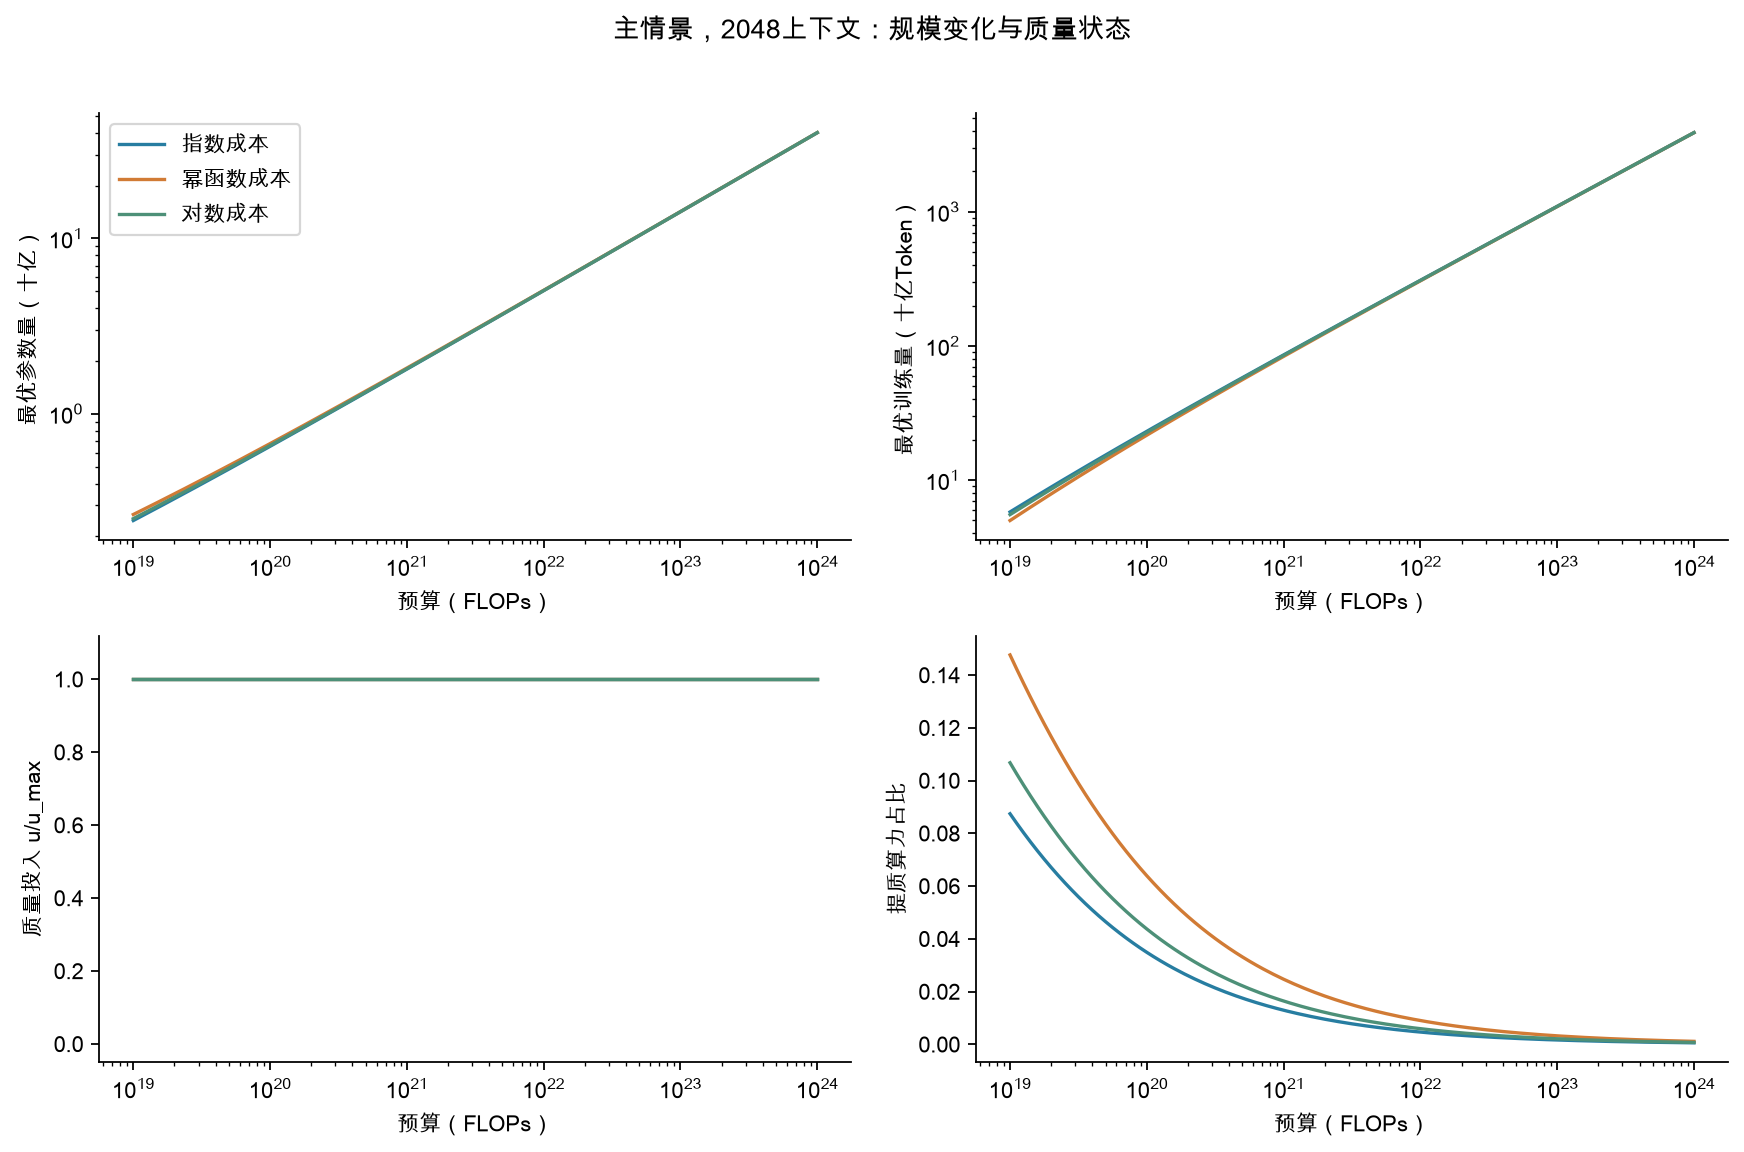

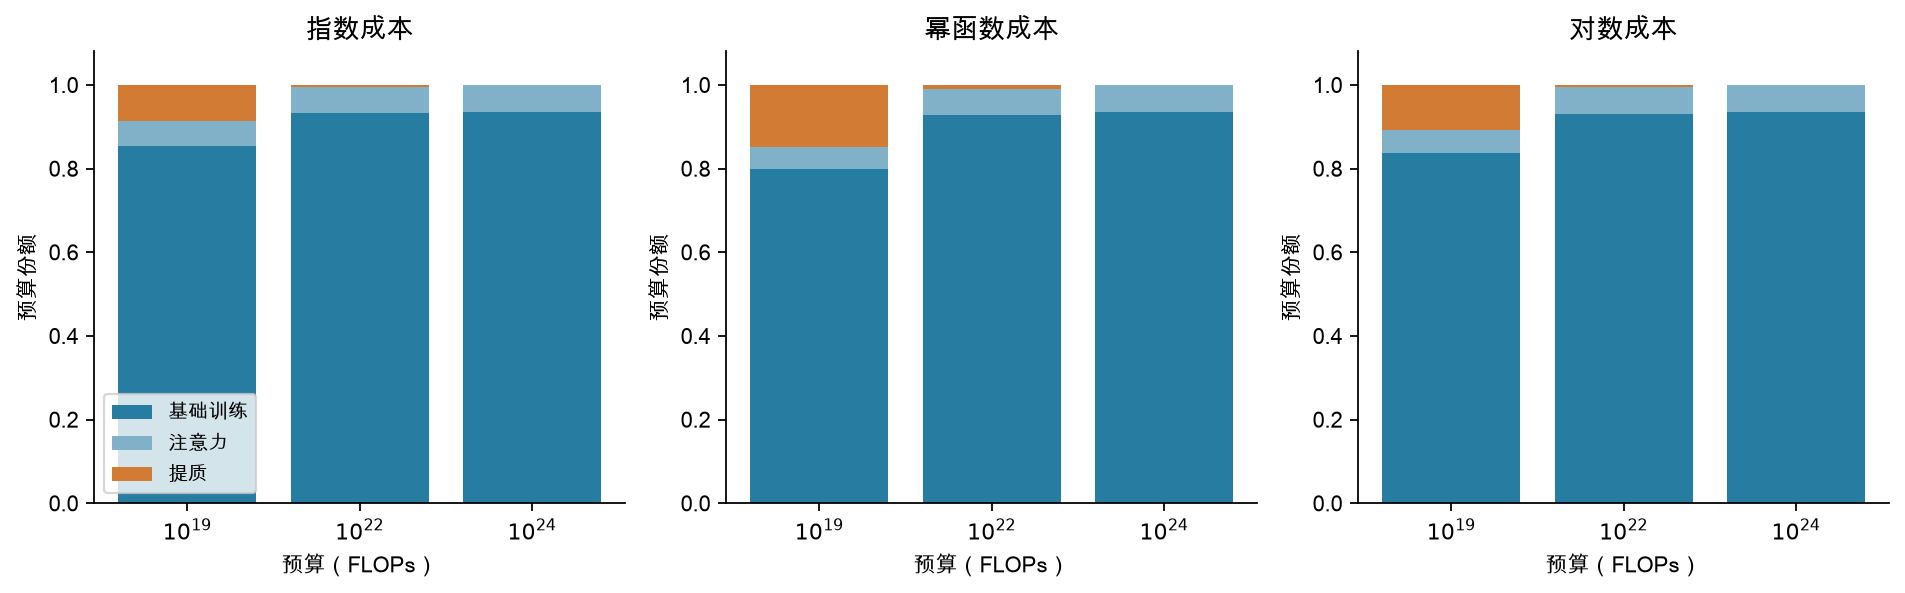

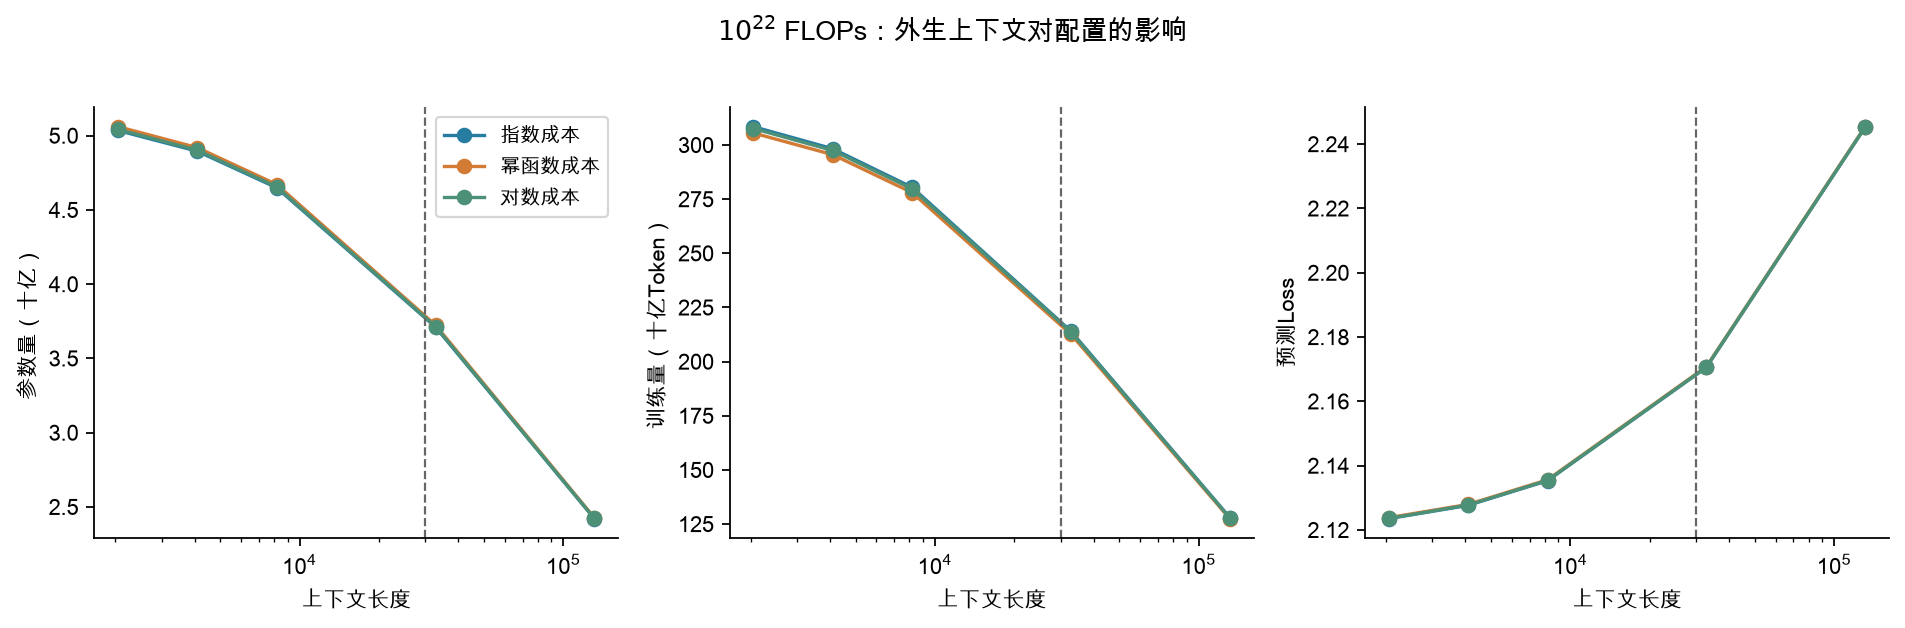

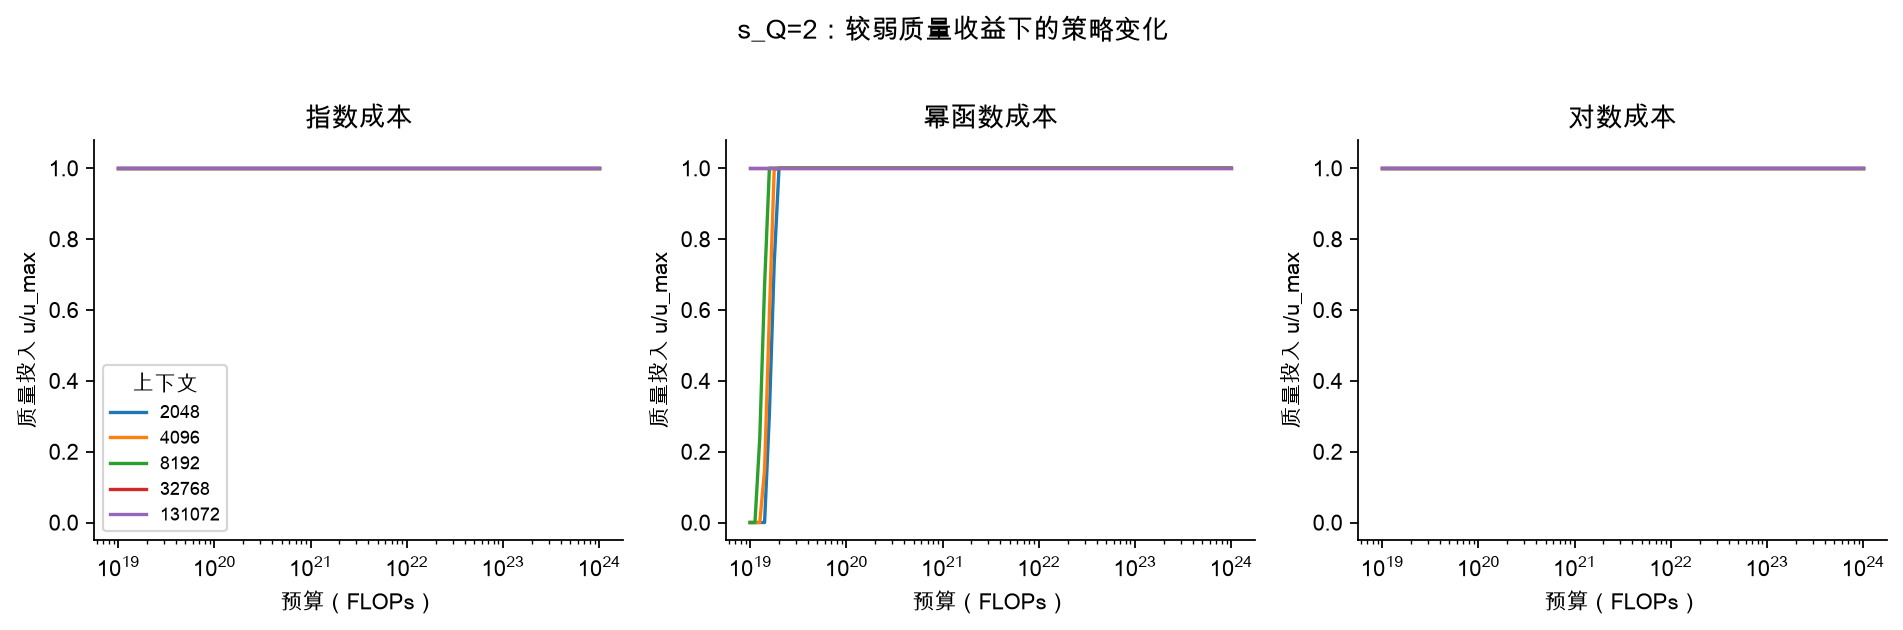

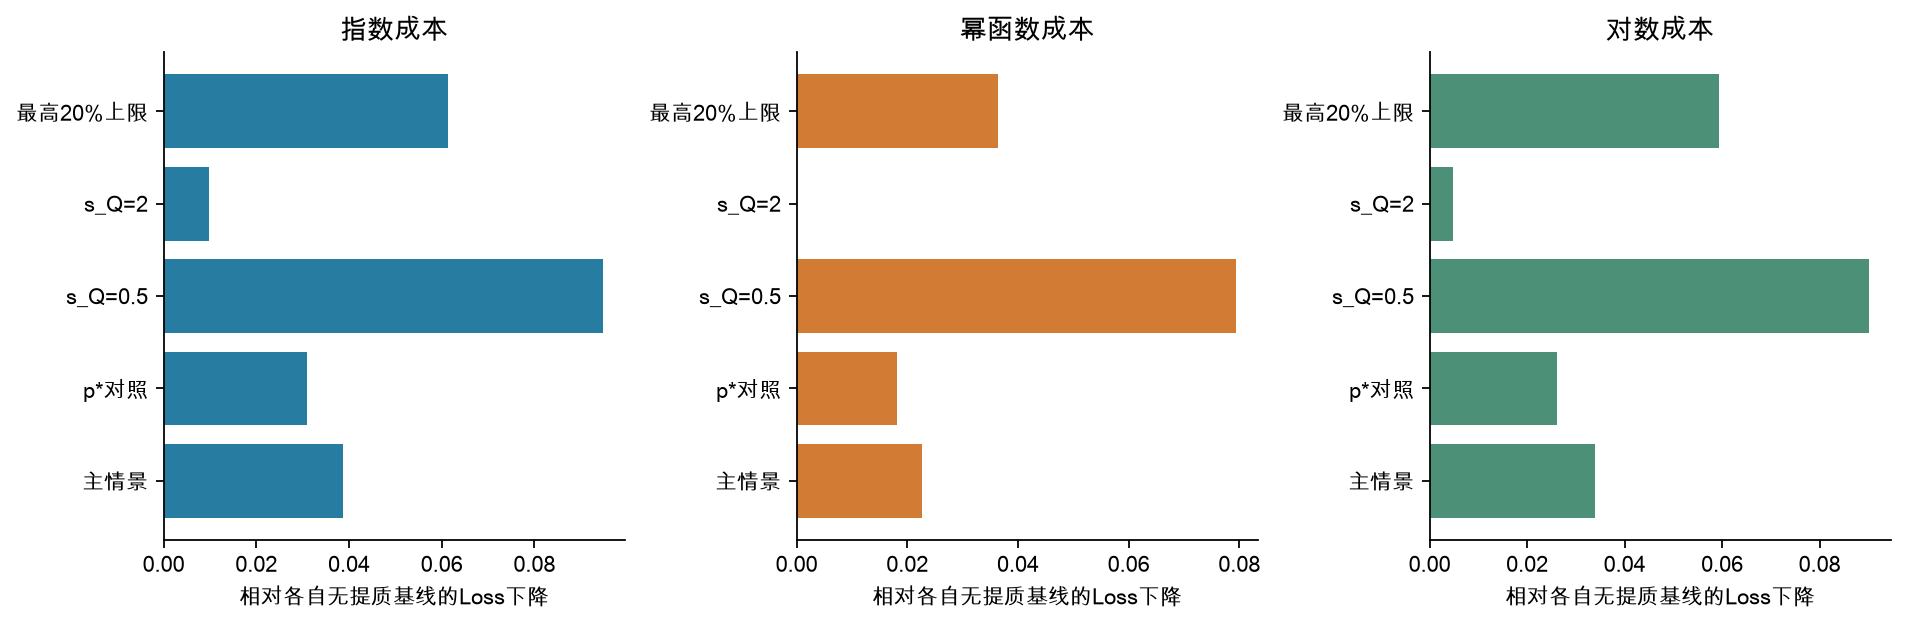

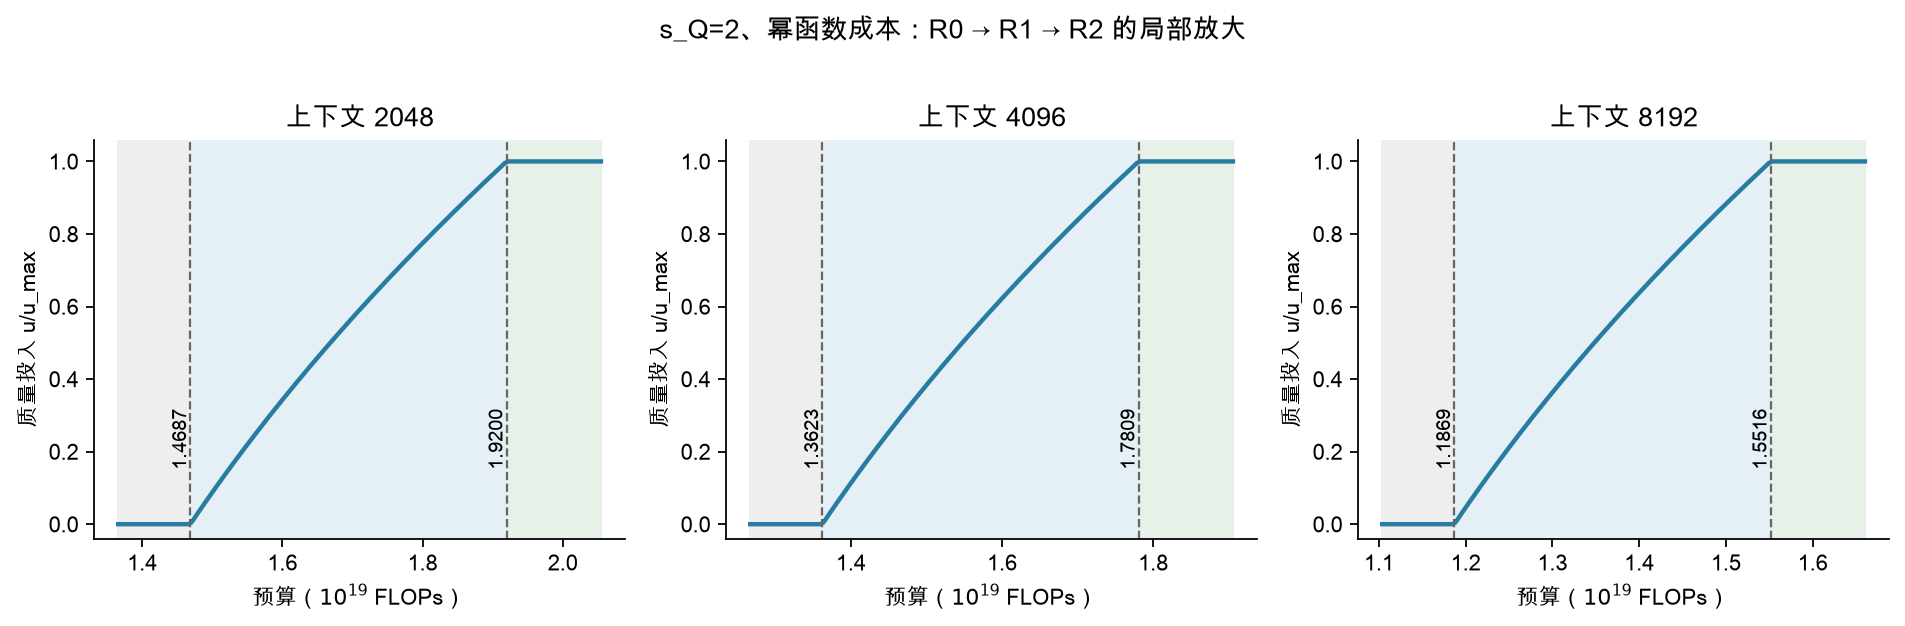

In [7]:
def finish(fig,name):
    fig.tight_layout()
    fig.savefig(FIG/f'{name}.png',bbox_inches='tight')
    fig.savefig(FIG/f'{name}.pdf',bbox_inches='tight')
    plt.close(fig);display(Image(filename=str(FIG/f'{name}.png')))
colors={'exponential':'#277DA1','power':'#D17B35','logarithmic':'#4D9078'}
fig,axes=plt.subplots(2,2,figsize=(11,7))
for cost in COSTS:
    d=scan.loc[scan.L_ctx.eq(2048)&scan.cost.eq(cost)]
    for ax,col,title in zip(axes.flat,['N_B','D_B','t','share_quality'],['最优参数量（十亿）','最优训练量（十亿Token）','质量投入 u/u_max','提质算力占比']):
        ax.plot(d.C,d[col],color=colors[cost],label=COST_LABELS[cost]);ax.set_xscale('log');ax.set(xlabel='预算（FLOPs）',ylabel=title)
        if col in ['N_B','D_B']:ax.set_yscale('log')
        if col=='t':ax.set_ylim(-.05,1.12)
axes[0,0].legend();fig.suptitle('主情景，2048上下文：规模变化与质量状态',y=1.02)
finish(fig,'01_budget_allocation')
fig,axes=plt.subplots(1,3,figsize=(12,3.8))
for ax,cost in zip(axes,COSTS):
    d=main.loc[main.cost.eq(cost)&main.L_ctx.eq(2048)].sort_values('C');x=np.arange(3);bottom=np.zeros(3)
    for col,label,color in [('share_train','基础训练','#277DA1'),('share_att','注意力','#81B1C8'),('share_quality','提质','#D17B35')]:
        ax.bar(x,d[col],bottom=bottom,label=label,color=color);bottom+=d[col].to_numpy()
    ax.set(xticks=x,xticklabels=['$10^{19}$','$10^{22}$','$10^{24}$'],xlabel='预算（FLOPs）',ylabel='预算份额',title=COST_LABELS[cost],ylim=(0,1.08))
axes[0].legend(fontsize=9);finish(fig,'02_cost_shares')
fig,axes=plt.subplots(1,3,figsize=(12,3.8))
for ax,col,title in zip(axes,['N_B','D_B','loss'],['参数量（十亿）','训练量（十亿Token）','预测Loss']):
    for cost in COSTS:
        d=main.loc[main.C.eq(1e22)&main.cost.eq(cost)].sort_values('L_ctx')
        ax.plot(d.L_ctx,d[col],'o-',label=COST_LABELS[cost],color=colors[cost])
    ax.axvline(30000,color='#666666',ls='--',lw=1);ax.set_xscale('log');ax.set(xlabel='上下文长度',ylabel=title)
axes[0].legend(fontsize=9);fig.suptitle('$10^{22}$ FLOPs：外生上下文对配置的影响',y=1.02);finish(fig,'03_context_sensitivity')
fig,axes=plt.subplots(1,3,figsize=(12,3.8))
sq2=sens_scan.loc[sens_scan.scenario.eq('sQ_2')]
for ax,cost in zip(axes,COSTS):
    for ctx in contexts:
        d=sq2.loc[sq2.cost.eq(cost)&sq2.L_ctx.eq(ctx)]
        ax.plot(d.C,d.t,label=str(ctx))
    ax.set_xscale('log');ax.set(xlabel='预算（FLOPs）',ylabel='质量投入 u/u_max',title=COST_LABELS[cost],ylim=(-.05,1.08))
axes[0].legend(title='上下文',fontsize=8);fig.suptitle('s_Q=2：较弱质量收益下的策略变化',y=1.02);finish(fig,'04_quality_transitions')
fig,axes=plt.subplots(1,3,figsize=(12,4))
labels={'main':'主情景','p_star':'p*对照','sQ_0.5':'s_Q=0.5','sQ_2':'s_Q=2','keep_20pct':'最高20%上限'}
combined=pd.concat([main,sensitivity],ignore_index=True)
for ax,cost in zip(axes,COSTS):
    d=combined.loc[combined.C.eq(1e19)&combined.L_ctx.eq(2048)&combined.cost.eq(cost)].set_index('scenario').loc[list(labels)]
    ax.barh(np.arange(len(labels)),d.loss_gain,color=colors[cost]);ax.set(yticks=np.arange(len(labels)),yticklabels=list(labels.values()),xlabel='相对各自无提质基线的Loss下降',title=COST_LABELS[cost])
finish(fig,'05_sensitivity_gain')
if len(zoom):
    fig,axes=plt.subplots(1,3,figsize=(12,3.8))
    for ax,ctx in zip(axes,sorted(zoom.L_ctx.unique())):
        d=zoom.loc[zoom.L_ctx.eq(ctx)].sort_values('C')
        cuts=transitions.loc[transitions.scenario.eq('sQ_2')&transitions.cost.eq('power')&transitions.L_ctx.eq(ctx)&transitions.C_critical.notna()].sort_values('C_critical')
        a,b=cuts.C_critical.to_numpy()/1e19
        ax.axvspan(d.C.min()/1e19,a,color='#EEEEEE');ax.axvspan(a,b,color='#E4F0F5');ax.axvspan(b,d.C.max()/1e19,color='#E7F1E8')
        ax.plot(d.C/1e19,d.t,color='#277DA1',lw=2)
        ax.axvline(a,color='#666666',ls='--',lw=1);ax.axvline(b,color='#666666',ls='--',lw=1)
        ax.text(a,.15,f'{a:.4f}',rotation=90,ha='right',va='bottom',fontsize=9)
        ax.text(b,.15,f'{b:.4f}',rotation=90,ha='right',va='bottom',fontsize=9)
        ax.set(xlabel='预算（$10^{19}$ FLOPs）',ylabel='质量投入 u/u_max',title=f'上下文 {ctx}',ylim=(-.04,1.06))
    fig.suptitle('s_Q=2、幂函数成本：R0 → R1 → R2 的局部放大',y=1.02)
    finish(fig,'06_transition_zoom')

In [8]:
# Export evidence-backed conclusions only after all experiments and checks.
full=pd.concat([main,scan,sensitivity,sens_scan,refinements,interior_cases,zoom],ignore_index=True)
assert full.budget_relative_error.max()<1e-12
assert (full.t>=-1e-12).all() and (full.t<=1+1e-12).all()
assert (full.z>0).all() and (full.z<=1).all()
assert full.loss_gain.min()>-1e-10
assert full.kkt_log_residual.max()<1e-9
assert all(sha(ROOT/p)==h for p,h in protected_before.items())
verification={'status':'passed','audit_passed':True,'protected_q1_q2_unchanged':True,
  'protected_sha256':protected_before,'main_rows':len(main),'budget_scan_rows':len(scan),
  'sensitivity_rows':len(sensitivity),'sensitivity_scan_rows':len(sens_scan),
  'max_budget_relative_error':float(full.budget_relative_error.max()),
  'max_inner_KKT_log_residual':float(full.kkt_log_residual.max()),
  'max_derivative_relative_error':float(validation.derivative_relative_error.max()),
  'max_classic_N_relative_error':float(validation.classic_N_relative_error.max()),
  'max_expanded_bracket_relative_error':float(validation.expanded_bracket_relative_error.max()),
  'max_outer_grid_relative_error':float(all_grid.loss_relative_difference.max()),
  'max_outer_grid_t_difference':float(all_grid.t_difference.max()),
  'independent_cases':len(independent),'max_independent_objective_relative_error':float(independent.independent_relative_objective_error.max()),
  'independent_quality_states':sorted(independent.state.unique()),
  'max_transition_analytic_relative_error':float(transition_checks.relative_difference.max()) if len(transition_checks) else 0.,
  'main_states':sorted(main.state.unique()),'scan_states':sorted(scan.state.unique()),
  'transitions_detected':int(transitions.C_critical.notna().sum()),
  'limits':'Numerical cross-checks are not empirical training validation or an interval-arithmetic proof of global optimality.'}
dump(verification,'verification.json')
manifest_paths=protected+[c7_path,ROOT/'算力约束下提升大语言模型能力的资源配置建模.docx',
 ROOT/'Q3/quality_audit/anchor_sensitivity.csv',ROOT/'Q3/quality_audit/quality_cap_candidates.csv',
 ROOT/'Q3/quality_audit/input_manifest.json',ROOT/'Q3/resource_model.py',ROOT/'Q3/notebook_source.py']
for file in ['pythia_training_log_existing.csv','supplementary_NQ_experiment_expanded.csv']:
    manifest_paths.append(ROOT/'real_attachments/B_scaling_laws'/file)
dump([{'path':str(p.relative_to(ROOT)),'bytes':p.stat().st_size,'sha256':sha(p)} for p in manifest_paths],'input_manifest.json')
interface={**config,'model':'E_B+(A_B*N**(-alpha)+B_B*D**(-nu))*exp(-theta_Q*u/s_Q+eta_p*h(p))',
 'quality_cap_rule':'within-domain top-r document mean increments, existing mapping kappa, missing domains zero gain',
 'state_rule':{'R0':'u=0','R1':'0<u<u_max','R2':'u=u_max'},
 'artifacts':{'main':'tables/main_results.csv','scan':'tables/budget_scan.csv','sensitivity':'tables/sensitivity_results.csv','transitions':'tables/transitions.csv'},
 'quality_gain_observed_training':False,'joint_transfer_validated':False,'s_Q_identified':False,
 'extrapolation_flags':['within_B1_ND_rectangle','within_B7_ND_rectangle','quality_positive_extrapolation','mixture_transfer_assumption'],
 'q2_interface_sha256':sha(protected[-1])}
dump(interface,'q3_interface.json')
actual_transitions=transitions.loc[transitions.C_critical.notna()]
lines=['# 问题三实际运行结果','',
 f'主情景：p0，s_Q=1，各域最高50%文档均值增量上限u_max={main_sc.cap:.6f}。采用B1损失基线及题设三类成本。',
 f'三档预算、五个上下文和三类成本共{len(main)}个配置；主预算扫描为{len(scan)}个点，状态集合为{sorted(scan.state.unique())}。',
 '主情景在研究窗口内未检测到质量状态转移。全程达到样本参照上限，表示上限在这些假设下持续活跃，不是自然质量饱和的实证发现。' if len(scan.state.unique())==1 and scan.state.iloc[0]=='R2' else '主情景状态变化见transitions.csv。',
 '', '2048上下文主结果（N和D均以十亿计）：','',
 '|预算|成本|N|D|u|预测Loss|相对无提质Loss下降|','|---|---|---:|---:|---:|---:|---:|']
for r in main.loc[main.L_ctx.eq(2048)].itertuples(index=False):
    lines.append(f'|{r.C:.0e}|{COST_LABELS[r.cost]}|{r.N_B:.4f}|{r.D_B:.4f}|{r.u:.6f}|{r.loss:.6f}|{r.loss_gain:.6f}|')
lines+=['','敏感性中检测到的转移：']
for r in actual_transitions.itertuples(index=False):
    lines.append(f'- {r.scenario}，{COST_LABELS[r.cost]}，上下文{r.L_ctx}：{r.from_state}→{r.to_state}，C≈{r.C_critical:.6e} FLOPs。')
if not len(actual_transitions):lines.append('- 所有已扫描敏感性情景均未检测到转移。')
lines+=['',f'验证：{len(independent)}组独立二维优化对照，最大可约损失相对差{verification["max_independent_objective_relative_error"]:.3e}；最大预算相对残差{verification["max_budget_relative_error"]:.3e}。',
 '局限：质量响应来自半合成实验且u>0向基准以上外推；s_Q未识别；高预算N/D超出观测覆盖；同一D成本代理不保证原料供给；p*对照依赖跨来源配比修正。当前结果是条件最优预测，不是实测训练最优。']
summary='\n'.join(lines)+'\n';(OUT/'results_summary.md').write_text(summary);show(summary)
show('解释：在主情景中质量上限始终活跃，预算增加主要扩张N和D；提质成本占比下降不等于质量投入下降。s_Q=2降低单位原始质量增量的预测收益，因而在低预算幂函数成本下出现R0/R1。更长上下文挤压规模扩张收益，转移预算可能降低，但同预算的绝对预测Loss仍升高，不能解读为长上下文更便宜。')
recipe_gain=recipe_comparison.predicted_pstar_loss_reduction
show(f'p*相对p0的同预算预测Loss差改善范围为{recipe_gain.min():.6f}—{recipe_gain.max():.6f}；这依赖配比修正跨来源迁移。p*的提质上限较低，不能只看提质增量判断最终Loss优劣。质量刻度、样本参照上限和同一D代理仍是已确认假设，不被数值核验消除。')
# Methodology is written after experiments but contains only definitions and methods.
method=r'''# 问题三模型建立

本问将前两问的质量评价和共同修正标度律转为算力预算下的条件资源配置。领域配比采用参考配比，预测最优配比单独比较；上下文外生给定。质量原分数Q、同配比额外增量u与成本刻度z分别定义，避免混用评价刻度和成本比例。

$$Q_0(p)=\sum_jp_jQ_j,\quad u=Q-Q_0(p),\quad z=T(Q)=\frac{Q-q_{low}}{q_{high}-q_{low}}.$$

固定A1七域等权参考分位锚点；有样本映射的域根据域内高分文档均值构建质量增量参照，沿用映射系数，缺失域不计新增收益。由此给定u的紧区间，域内筛选供给不另行建模，沿用题目同一D成本代理。

$$\min_{N,D,u}\ E_B+(A_BN^{-\alpha}+B_BD^{-\nu})\exp[-\theta_Q u/s_Q+\eta_ph(p)]$$
$$\mathrm{s.t.}\quad D[kN+c(u)]\le C,\quad N,D>0,\quad 0\le u\le u_{max}(p).$$

其中N、D以十亿计，k包含基础训练与外生上下文注意力成本，c为每十亿训练Token的额外提质成本。三类g采用题设参数，分别完成优化。B1提供损失基线，质量刻度s_Q和配比修正迁移保留条件假设。

固定u时损失对D递减，故预算取等号。令x=ln N，消去D后内层目标严格凸，使用自适应括区间求根求唯一条件最优。外层结合网格定位、所有检测到的驻点、局部精化和两端点比较，避免预设单峰。

$$\alpha AN^{-\alpha}=\nu BD^{-\nu}\frac{kN}{kN+c},\qquad
M(u)=-\lambda(t_N+t_D)+\frac{\nu t_Dc'}{kN+c}.$$

质量状态定义为下界R0、内点R1和上界R2。预算扫描识别状态变化，再通过边界驻点方程和全局候选比较精化转移位置；数值搜索边界不作为物理边界。R2由u=u_max定义，与z=1无关。对配比、质量效果尺度和质量上限进行单因素敏感性分析。

验证包含预算单位与残差、无提质经典解析解、内层KKT、外层有限差分导数、扩大括区间、外层网格加密、独立二维优化及转移候选解析核验。误差容差和原始结果一起保存。模型检验不代替真实训练验证，也不证明样本筛选参照上限的原料供给可行性。
'''
(OUT/'模型建立.md').write_text(method)
solution=summary.replace('# 问题三实际运行结果','# 问题三模型求解',1)
solution+='\n## 结果解释与图件\n\n主预算区间质量上限持续活跃，N和D随预算增加而扩张；提质成本占比下降是预算分配变化，并非质量下降。图1展示规模和投入曲线，图2分解成本，图3显示上下文对规模和Loss的影响。\n\n'
for f,title in [('01_budget_allocation','预算配置'),('02_cost_shares','成本份额'),('03_context_sensitivity','上下文敏感性'),('04_quality_transitions','质量状态'),('05_sensitivity_gain','收益敏感性'),('06_transition_zoom','转移区间放大')]:
    solution+=f'![{title}](figures/{f}.png)\n\n'
solution+=f'p*对照相对p0的预测Loss改善为{recipe_gain.min():.6f}—{recipe_gain.max():.6f}，这一比较依赖配比修正迁移假设。质量上限较低并不意味着最终Loss更高。\n\n'
solution+='s_Q=2时，质量响应减弱，幂函数成本出现从不提质到部分提质再到样本参照上限的连续转移。更长上下文减少规模扩张的相对吸引力，转移预算降低；这不能抵消其对绝对Loss的不利影响。转移方程的解析候选与全局数值分支核验相符。\n'
(OUT/'模型求解.md').write_text(solution)
dump({'notebook':'0925_问题三.ipynb','mirror':'Q3/notebook_source.py','solver':'Q3/resource_model.py',
      'runner':'Q3/run_notebook.py','inputs':'input_manifest.json','results':'tables/','figures':'figures/',
      'summary':'results_summary.md','methodology':'模型建立.md','solution':'模型求解.md'},'artifact_manifest.json')

# 问题三实际运行结果

主情景：p0，s_Q=1，各域最高50%文档均值增量上限u_max=0.113672。采用B1损失基线及题设三类成本。
三档预算、五个上下文和三类成本共45个配置；主预算扫描为3015个点，状态集合为['R2']。
主情景在研究窗口内未检测到质量状态转移。全程达到样本参照上限，表示上限在这些假设下持续活跃，不是自然质量饱和的实证发现。

2048上下文主结果（N和D均以十亿计）：

|预算|成本|N|D|u|预测Loss|相对无提质Loss下降|
|---|---|---:|---:|---:|---:|---:|
|1e+19|指数成本|0.2461|5.7846|0.113672|2.960223|0.038703|
|1e+19|幂函数成本|0.2664|4.9911|0.113672|2.976312|0.022614|
|1e+19|对数成本|0.2523|5.5229|0.113672|2.965093|0.033833|
|1e+22|指数成本|5.0344|308.4554|0.113672|2.123509|0.019675|
|1e+22|幂函数成本|5.0602|305.5316|0.113672|2.123805|0.019378|
|1e+22|对数成本|5.0419|307.5958|0.113672|2.123595|0.019588|
|1e+24|指数成本|40.0814|3890.1880|0.113672|1.903565|0.009837|
|1e+24|幂函数成本|40.1076|3885.4660|0.113672|1.903584|0.009819|
|1e+24|对数成本|40.0890|3888.8100|0.113672|1.903571|0.009832|

敏感性中检测到的转移：
- sQ_2，幂函数成本，上下文2048：R0→R1，C≈1.468735e+19 FLOPs。
- sQ_2，幂函数成本，上下文2048：R1→R2，C≈1.920026e+19 FLOPs。
- sQ_2，幂函数成本，上下文4096：R0→R1，C≈1.362276e+19 FLOPs。
- sQ_2，幂函数成本，上下文4096：R1→R2，C≈1.780855e+19 FLOPs。
- sQ_2，幂函数成本，上下文8192：R0→R1，C≈1.186911e+19 FLOPs。
- sQ_2，幂函数成本，上下文8192：R1→R2，C≈1.551606e+19 FLOPs。

验证：33组独立二维优化对照，最大可约损失相对差2.276e-15；最大预算相对残差4.950e-16。
局限：质量响应来自半合成实验且u>0向基准以上外推；s_Q未识别；高预算N/D超出观测覆盖；同一D成本代理不保证原料供给；p*对照依赖跨来源配比修正。当前结果是条件最优预测，不是实测训练最优。


解释：在主情景中质量上限始终活跃，预算增加主要扩张N和D；提质成本占比下降不等于质量投入下降。s_Q=2降低单位原始质量增量的预测收益，因而在低预算幂函数成本下出现R0/R1。更长上下文挤压规模扩张收益，转移预算可能降低，但同预算的绝对预测Loss仍升高，不能解读为长上下文更便宜。

p*相对p0的同预算预测Loss差改善范围为0.004868—0.041085；这依赖配比修正跨来源迁移。p*的提质上限较低，不能只看提质增量判断最终Loss优劣。质量刻度、样本参照上限和同一D代理仍是已确认假设，不被数值核验消除。